# Model v1 – Hyperparameter Tuning: `max_depth`

Walk-forward evaluation (train on all years < test year) comparing XGBoost performance across `max_depth` values.  
Data filtered to draft classes **2000 and later**.

In [13]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from xgboost import XGBRegressor

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DRAFT_CSV = os.path.join(REPO_ROOT, 'src', 'data', 'raw', 'draft_picks.csv')
AV_DIR    = os.path.join(REPO_ROOT, 'scraping_av', 'data')
OUT_DIR   = os.path.join(REPO_ROOT, 'poc_outputs')
os.makedirs(OUT_DIR, exist_ok=True)

START_YEAR = 2000

## Load Data

In [14]:
def eval_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sp   = spearmanr(y_true, y_pred).correlation
    return mae, rmse, sp


def load_draft(draft_csv):
    df = pd.read_csv(draft_csv)
    df.columns = [c.strip() for c in df.columns]
    rename_map = {}
    if 'draft_season' in df.columns and 'season' not in df.columns:
        rename_map['draft_season'] = 'season'
    if rename_map:
        df = df.rename(columns=rename_map)
    needed = ['season', 'pick', 'round', 'team', 'position', 'category', 'side', 'age', 'college', 'pfr_player_id']
    keep = [c for c in needed if c in df.columns]
    df = df[keep].copy()
    df['season'] = df['season'].astype(int)
    df['pick']   = pd.to_numeric(df['pick'], errors='coerce')
    df = df.dropna(subset=['pick']).copy()
    df['pick'] = df['pick'].astype(int)
    if 'round' in df.columns:
        df['round'] = pd.to_numeric(df['round'], errors='coerce')
    if 'age' in df.columns:
        df['age']   = pd.to_numeric(df['age'], errors='coerce')
    for c in ['team', 'position', 'category', 'side', 'college']:
        if c in df.columns:
            df[c] = df[c].astype(str)
    return df


def load_av_from_year_files(av_dir):
    paths = sorted(glob.glob(os.path.join(av_dir, '*_av.csv')))
    if not paths:
        raise FileNotFoundError(f'No *_av.csv files found in {av_dir}')
    dfs = []
    for fp in paths:
        d = pd.read_csv(fp)
        d.columns = [c.strip() for c in d.columns]
        d = d.rename(columns={'Year': 'season', 'PlayerID': 'pfr_player_id', 'Player': 'player_name', 'AV': 'av'})
        needed = {'season', 'pfr_player_id', 'player_name', 'av'}
        if not needed.issubset(d.columns):
            raise ValueError(f'{fp} missing columns {needed}. Found: {d.columns.tolist()}')
        d = d[list(needed)].copy()
        d['season'] = pd.to_numeric(d['season'], errors='coerce').astype('Int64')
        d['av']     = pd.to_numeric(d['av'], errors='coerce').fillna(0.0)
        dfs.append(d)
    av_long = pd.concat(dfs, ignore_index=True)
    av_long = av_long.groupby(['season', 'pfr_player_id'], as_index=False).agg(
        player_name=('player_name', 'first'),
        av=('av', 'sum')
    )
    return av_long


def build_two_year_labels(av_long):
    a = av_long.rename(columns={'season': 'draft_season', 'av': 'av_y'})
    b = av_long.rename(columns={'season': 'next_season',  'av': 'av_y1'})[['next_season', 'pfr_player_id', 'av_y1']]
    merged = a.merge(b, on='pfr_player_id', how='left')
    merged = merged[merged['next_season'] == merged['draft_season'] + 1].copy()
    merged['av_2yr'] = merged['av_y'] + merged['av_y1'].fillna(0.0)
    return merged[['draft_season', 'pfr_player_id', 'av_2yr']]


print('Loading data...')
draft  = load_draft(DRAFT_CSV)
av_long = load_av_from_year_files(AV_DIR)
labels  = build_two_year_labels(av_long)

df = draft.rename(columns={'season': 'draft_season'}).merge(
    labels, on=['draft_season', 'pfr_player_id'], how='left'
)
df = df.dropna(subset=['av_2yr']).copy()
df = df[df['draft_season'] >= START_YEAR].copy()
df['av_2yr'] = df['av_2yr'].astype(float)

num_cols = [c for c in ['pick', 'round', 'age'] if c in df.columns]
cat_cols = [c for c in ['position', 'category', 'team', 'college', 'side'] if c in df.columns]

X     = df[num_cols + cat_cols].copy()
y     = df['av_2yr'].values
years = df['draft_season'].values
unique_years = sorted(np.unique(years))

print(f'Draft classes: {unique_years[0]}–{unique_years[-1]}  |  n={len(df)}')

Loading data...
Draft classes: 2000–2024  |  n=4547


## Walk-Forward Evaluation across `max_depth` values

In [15]:
MAX_DEPTHS = [2, 3, 4, 5, 6, 7]


def make_pipeline(max_depth):
    transformers = []
    if 'pick' in num_cols:
        transformers.append(('pick_spline', SplineTransformer(n_knots=6, degree=3, include_bias=False), ['pick']))
        other_nums = [c for c in num_cols if c != 'pick']
        if other_nums:
            transformers.append(('num_passthrough', 'passthrough', other_nums))
    else:
        transformers.append(('num_passthrough', 'passthrough', num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))
    pre = ColumnTransformer(transformers)
    return Pipeline([
        ('pre', pre),
        ('xgb', XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0,
            tree_method='hist',  # histogram-based splits, much faster on CPU (incl. M1)
            nthread=-1           # use all available cores
        ))
    ])


all_results = []
for depth in MAX_DEPTHS:
    model = make_pipeline(depth)
    for test_year in unique_years[1:]:
        train_mask = years < test_year
        test_mask  = years == test_year
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            continue
        model.fit(X[train_mask], y[train_mask])
        pred = model.predict(X[test_mask])
        mae, rmse, sp = eval_metrics(y[test_mask], pred)
        all_results.append({'max_depth': depth, 'test_year': int(test_year),
                            'mae': mae, 'rmse': rmse, 'spearman': sp})
    print(f'  max_depth={depth} done')

results_df = pd.DataFrame(all_results)
print('Done.')

  max_depth=2 done
  max_depth=3 done
  max_depth=4 done
  max_depth=5 done
  max_depth=6 done
  max_depth=7 done
Done.


## Results

In [16]:
summary = results_df.groupby('max_depth')[['mae', 'rmse', 'spearman']].mean().round(3)
print('Average metrics across all walk-forward test years:')
summary

Average metrics across all walk-forward test years:


,mae,rmse,spearman
max_depth,,,
2,3.416,4.607,0.556
3,3.460,4.671,0.546
4,3.505,4.732,0.533
5,3.543,4.771,0.525
6,3.563,4.808,0.520
7,3.600,4.855,0.511


Saved: /Users/arnav/Desktop/STATS170A/DraftSight/poc_outputs/plot_xgb_maxdepth_tuning.png


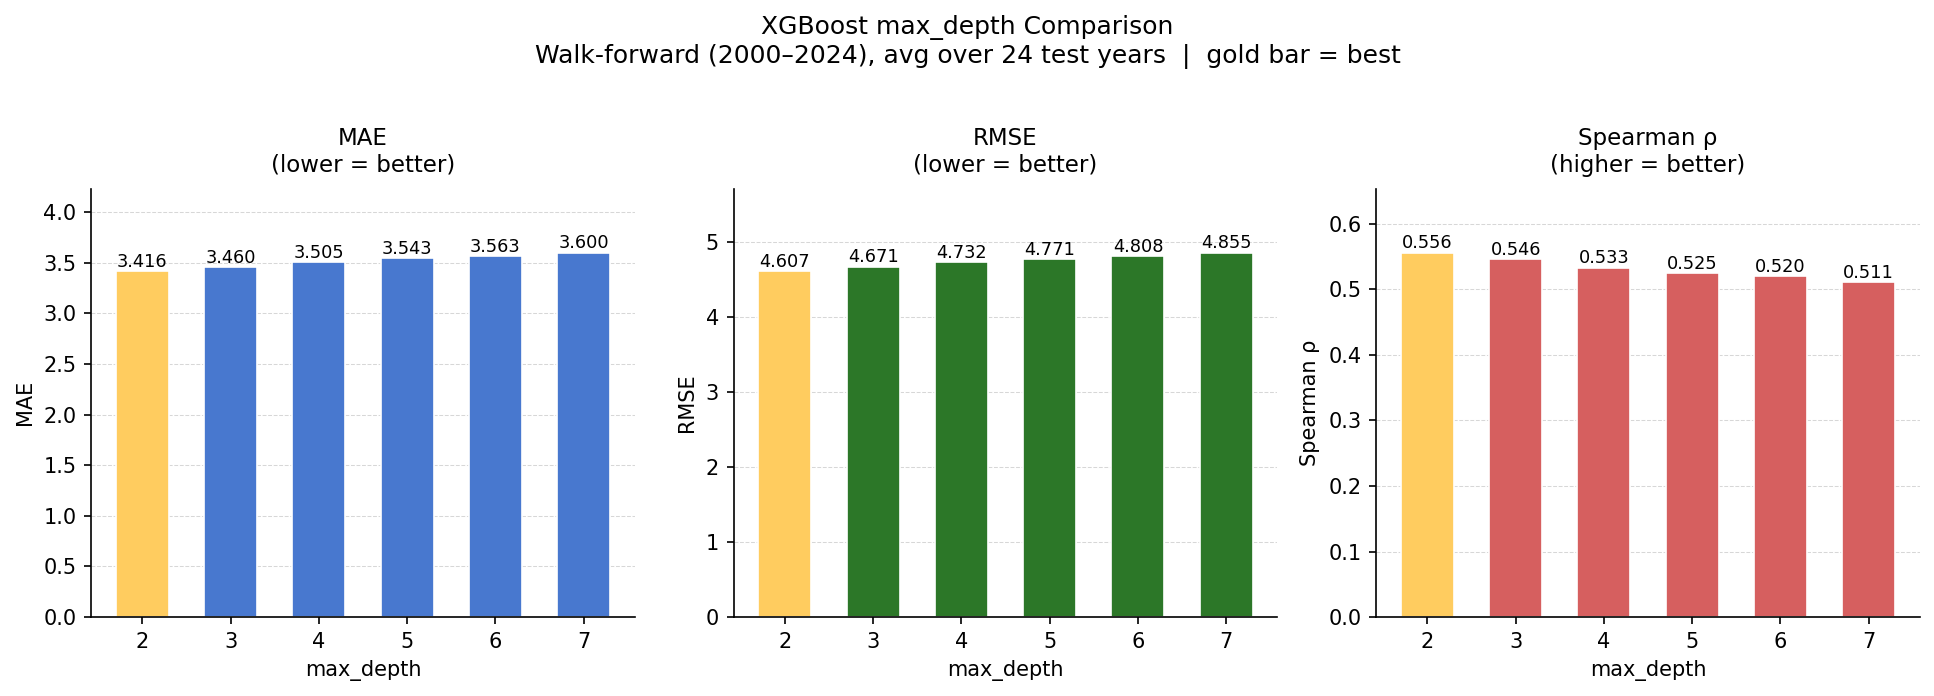

In [17]:
METRICS = [
    ('mae',      'MAE',       True,  '#4878CF'),
    ('rmse',     'RMSE',      True,  "#2C7728"),
    ('spearman', 'Spearman ρ', False, '#D65F5F'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), dpi=150)

for ax, (col, label, lower_better, color) in zip(axes, METRICS):
    vals = summary[col]
    best = vals.idxmin() if lower_better else vals.idxmax()

    bar_colors = [color if d != best else "#FFCC5F" for d in summary.index]
    bars = ax.bar(summary.index, vals, color=bar_colors, width=0.6, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (vals.max() - vals.min()) * 0.015,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5
        )

    direction = 'lower = better' if lower_better else 'higher = better'
    ax.set_title(f'{label}\n({direction})', fontsize=11, pad=8)
    ax.set_xlabel('max_depth', fontsize=10)
    ax.set_xticks(MAX_DEPTHS)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ylo, yhi = ax.get_ylim()
    ax.set_ylim(ylo, yhi + (yhi - ylo) * 0.12)

fig.suptitle(
    f'XGBoost max_depth Comparison\n'
    f'Walk-forward ({unique_years[0]}–{unique_years[-1]}), avg over {len(unique_years)-1} test years  |  gold bar = best',
    fontsize=12, y=1.02
)
fig.tight_layout()

out_path = os.path.join(OUT_DIR, 'plot_xgb_maxdepth_tuning.png')
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()